In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the custom CSV dataset (Breast Cancer Diagnosis)
df = pd.read_csv("breast_cancer_real_dataset.csv")

# 2. Assign Features (X) and Target (y)
feature_cols = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'smoothness_mean', 'concavity_mean']
X = df[feature_cols].values
y_raw = df['diagnosis'].values

# Encode target labels (Benign/Malignant -> 0/1)
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Feature Names:", feature_cols)
print("Target Names:", list(le.classes_), "->", list(le.transform(le.classes_)))

# 3. Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Initialize and train the SVM Model
model = SVC(
    kernel='rbf',      # Kernel type (works well for overlapping, non-linear classes)
    C=1.0,             # Regularization parameter
    gamma='scale',     # Kernel coefficient
    random_state=42
)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Feature Names: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'concavity_mean']
Target Names: ['Benign', 'Malignant'] -> [0, 1]

Accuracy: 0.9473684210526315

Confusion Matrix:
[[70  2]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.97      0.96        72
   Malignant       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



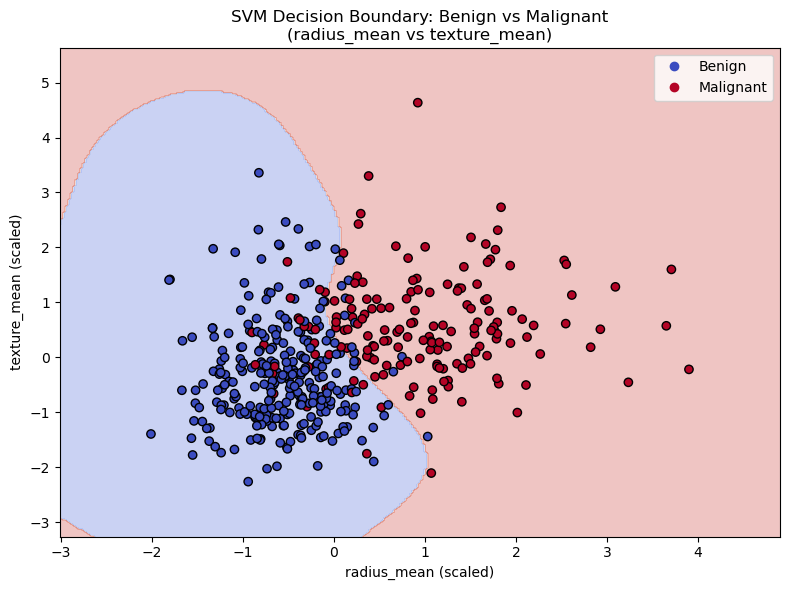

In [2]:
# 7. Visualize decision boundary using first 2 features (for illustration)
X_vis = X[:, :2]  # radius_mean vs texture_mean
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y, test_size=0.2, random_state=42, stratify=y
)

scaler_vis = StandardScaler()
X_train_vis = scaler_vis.fit_transform(X_train_vis)
X_test_vis = scaler_vis.transform(X_test_vis)

model_vis = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_vis.fit(X_train_vis, y_train_vis)

x_min, x_max = X_train_vis[:, 0].min() - 1, X_train_vis[:, 0].max() + 1
y_min, y_max = X_train_vis[:, 1].min() - 1, X_train_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1],
                       c=y_train_vis, cmap='coolwarm', edgecolors='k')
plt.xlabel('radius_mean (scaled)')
plt.ylabel('texture_mean (scaled)')
plt.title('SVM Decision Boundary: Benign vs Malignant\n(radius_mean vs texture_mean)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))
plt.tight_layout()
plt.savefig("svm_decision_boundary.png", dpi=150)
plt.show()